# House Price Prediction Using Machine Learning 

In [222]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

pd.set_option('display.max_rows', None)
pd.options.display.float_format = '{:.2f}'.format

In [223]:
train_data = pd.read_csv(r"train.csv")
train_data.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.00,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.00,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [224]:
train_data.shape

(1460, 81)

In [225]:
test_data = pd.read_csv(r"test.csv")
test_data.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.00,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.00,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.00,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.00,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.00,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [226]:
test_ids = test_data['Id'].values.tolist()

### Data Cleaning

In [227]:
train_data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [228]:
train_data.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
Street            object
Alley             object
LotShape          object
LandContour       object
Utilities         object
LotConfig         object
LandSlope         object
Neighborhood      object
Condition1        object
Condition2        object
BldgType          object
HouseStyle        object
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
RoofStyle         object
RoofMatl          object
Exterior1st       object
Exterior2nd       object
MasVnrType        object
MasVnrArea       float64
ExterQual         object
ExterCond         object
Foundation        object
BsmtQual          object
BsmtCond          object
BsmtExposure      object
BsmtFinType1      object
BsmtFinSF1         int64
BsmtFinType2      object
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
Heating           object


In [229]:
train_data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.00,1460.00,1201.00,1460.00,1460.00,1460.00,1460.00,1460.00,1452.00,1460.00,...,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00
mean,730.50,56.90,70.05,10516.83,6.10,5.58,1971.27,1984.87,103.69,443.64,...,94.24,46.66,21.95,3.41,15.06,2.76,43.49,6.32,2007.82,180921.20
std,421.61,42.30,24.28,9981.26,1.38,1.11,30.20,20.65,181.07,456.10,...,125.34,66.26,61.12,29.32,55.76,40.18,496.12,2.70,1.33,79442.50
min,1.00,20.00,21.00,1300.00,1.00,1.00,1872.00,1950.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,2006.00,34900.00
25%,365.75,20.00,59.00,7553.50,5.00,5.00,1954.00,1967.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.00,2007.00,129975.00
50%,730.50,50.00,69.00,9478.50,6.00,5.00,1973.00,1994.00,0.00,383.50,...,0.00,25.00,0.00,0.00,0.00,0.00,0.00,6.00,2008.00,163000.00
75%,1095.25,70.00,80.00,11601.50,7.00,6.00,2000.00,2004.00,166.00,712.25,...,168.00,68.00,0.00,0.00,0.00,0.00,0.00,8.00,2009.00,214000.00
max,1460.00,190.00,313.00,215245.00,10.00,9.00,2010.00,2010.00,1600.00,5644.00,...,857.00,547.00,552.00,508.00,480.00,738.00,15500.00,12.00,2010.00,755000.00


In [230]:
train_data.isna().sum()

Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinSF1          0
BsmtFinType2       38
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFin

In [231]:
test_data.isna().sum()

Id                  0
MSSubClass          0
MSZoning            4
LotFrontage       227
LotArea             0
Street              0
Alley            1352
LotShape            0
LandContour         0
Utilities           2
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         1
Exterior2nd         1
MasVnrType        894
MasVnrArea         15
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           44
BsmtCond           45
BsmtExposure       44
BsmtFinType1       42
BsmtFinSF1          1
BsmtFinType2       42
BsmtFinSF2          1
BsmtUnfSF           1
TotalBsmtSF         1
Heating             0
HeatingQC           0
CentralAir          0
Electrical          0
1stFlrSF            0
2ndFlrSF            0
LowQualFin

Fill the columns NA vals using data description

In [232]:
# cols whose na values could require imputation
impute_most_frq_cols = ['MSSubClass','MSZoning','Street','LotShape','LandContour','Utilities','LotConfig','LandSlope',
                        'Neighborhood','Condition1','Condition2','BldgType','HouseStyle','RoofStyle','RoofMatl','Exterior1st',
                        'Exterior2nd','ExterQual','ExterCond','Foundation','Heating','HeatingQC','CentralAir','Electrical',
                        'BsmtFullBath','BsmtHalfBath','FullBath','HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual','Fireplaces','GarageCars',
                        'PavedDrive','SaleType','SaleCondition', 'Functional']

# cols whose na values can be filled with median
impute_median_cols = ['LotFrontage','LotArea','OverallQual','OverallCond','MasVnrArea','BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF',
                        '1stFlrSF','2ndFlrSF','LowQualFinSF','GrLivArea','TotRmsAbvGrd','GarageArea','WoodDeckSF',
                        'OpenPorchSF','EnclosedPorch','3SsnPorch','ScreenPorch','PoolArea','MiscVal', 
                        'YearBuilt', 'YearRemodAdd', 'MoSold', 'YrSold']

# cols whose na values can be filled with default text values (like 'None' or 'No Garage')
fill_default_cols = ['Alley','MasVnrType','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','FireplaceQu','GarageType',
                        'GarageFinish','GarageQual','GarageCond','PoolQC','Fence','MiscFeature']

# cols whose na values can be filled with 0
# (GarageYrBlt is kept here because if a house has no garage, a 0 is a safe placeholder before scaling/binarizing)
fill_0_default_cols = ['GarageYrBlt']

Alley

In [233]:
train_data['Alley'] = train_data['Alley'].fillna('No alley')
test_data['Alley'] = test_data['Alley'].fillna('No alley')

In [234]:
train_data['Alley'].unique()

array(['No alley', 'Grvl', 'Pave'], dtype=object)

In [235]:
test_data['Alley'].unique()

array(['No alley', 'Pave', 'Grvl'], dtype=object)

MasVnrType

In [236]:
train_data['MasVnrType'] = train_data['MasVnrType'].fillna('None')
test_data['MasVnrType'] = test_data['MasVnrType'].fillna('None')

In [237]:
train_data['MasVnrType'].unique()

array(['BrkFace', 'None', 'Stone', 'BrkCmn'], dtype=object)

In [238]:
test_data['MasVnrType'].unique()

array(['None', 'BrkFace', 'Stone', 'BrkCmn'], dtype=object)

BsmtQual

In [239]:
train_data['BsmtQual'] = train_data['BsmtQual'].fillna('No Basement')
test_data['BsmtQual'] = test_data['BsmtQual'].fillna('No Basement')

In [240]:
train_data['BsmtQual'].unique()

array(['Gd', 'TA', 'Ex', 'No Basement', 'Fa'], dtype=object)

In [241]:
test_data['BsmtQual'].unique()

array(['TA', 'Gd', 'Ex', 'Fa', 'No Basement'], dtype=object)

BsmtCond

In [242]:
train_data['BsmtCond'] = train_data['BsmtCond'].fillna('No Basement')
test_data['BsmtCond'] = test_data['BsmtCond'].fillna('No Basement')

In [243]:
train_data['BsmtCond'].unique()

array(['TA', 'Gd', 'No Basement', 'Fa', 'Po'], dtype=object)

In [244]:
test_data['BsmtCond'].unique()

array(['TA', 'Po', 'Fa', 'Gd', 'No Basement'], dtype=object)

BsmtExposure

In [245]:
train_data['BsmtExposure'] = train_data['BsmtExposure'].fillna('No Basement')
test_data['BsmtExposure'] = test_data['BsmtExposure'].fillna('No Basement')      

In [246]:
train_data['BsmtExposure'].unique()

array(['No', 'Gd', 'Mn', 'Av', 'No Basement'], dtype=object)

In [247]:
test_data['BsmtExposure'].unique()

array(['No', 'Gd', 'Mn', 'Av', 'No Basement'], dtype=object)

BsmtFinType1

In [248]:
train_data['BsmtFinType1'] = train_data['BsmtFinType1'].fillna("No Basement")
test_data['BsmtFinType1'] = test_data['BsmtFinType1'].fillna("No Basement")

In [249]:
train_data['BsmtFinType1'].unique()

array(['GLQ', 'ALQ', 'Unf', 'Rec', 'BLQ', 'No Basement', 'LwQ'],
      dtype=object)

In [250]:
test_data['BsmtFinType1'].unique()

array(['Rec', 'ALQ', 'GLQ', 'Unf', 'BLQ', 'LwQ', 'No Basement'],
      dtype=object)

BsmtFinType2

In [251]:
train_data['BsmtFinType2'] = train_data['BsmtFinType2'].fillna('No Basement')
test_data['BsmtFinType2'] = test_data['BsmtFinType2'].fillna('No Basement')

In [252]:
train_data['BsmtFinType2'].unique()

array(['Unf', 'BLQ', 'No Basement', 'ALQ', 'Rec', 'LwQ', 'GLQ'],
      dtype=object)

In [253]:
test_data['BsmtFinType2'].unique()

array(['LwQ', 'Unf', 'Rec', 'BLQ', 'GLQ', 'ALQ', 'No Basement'],
      dtype=object)

FireplaceQu

In [254]:
train_data['FireplaceQu'] = train_data['FireplaceQu'].fillna('No Fireplace')
test_data['FireplaceQu'] = test_data['FireplaceQu'].fillna('No Fireplace')

In [255]:
train_data['FireplaceQu'].unique()

array(['No Fireplace', 'TA', 'Gd', 'Fa', 'Ex', 'Po'], dtype=object)

In [256]:
test_data['FireplaceQu'].unique()

array(['No Fireplace', 'TA', 'Gd', 'Po', 'Fa', 'Ex'], dtype=object)

GarageType 

In [257]:
train_data['GarageType'] = train_data['GarageType'].fillna('No Garage')
test_data['GarageType'] = test_data['GarageType'].fillna('No Garage')

In [258]:
train_data['GarageType'].unique()

array(['Attchd', 'Detchd', 'BuiltIn', 'CarPort', 'No Garage', 'Basment',
       '2Types'], dtype=object)

In [259]:
test_data['GarageType'].unique()

array(['Attchd', 'Detchd', 'BuiltIn', 'No Garage', 'Basment', '2Types',
       'CarPort'], dtype=object)

GarageFinish

In [260]:
train_data['GarageFinish'] = train_data['GarageFinish'].fillna('No Garage')
test_data['GarageFinish'] = test_data['GarageFinish'].fillna('No Garage')

In [261]:
train_data['GarageFinish'].unique()

array(['RFn', 'Unf', 'Fin', 'No Garage'], dtype=object)

In [262]:
test_data['GarageFinish'].unique()

array(['Unf', 'Fin', 'RFn', 'No Garage'], dtype=object)

GarageQual

In [263]:
train_data['GarageQual'] = train_data['GarageQual'].fillna('No Garage')
test_data['GarageQual'] = test_data['GarageQual'].fillna('No Garage')

In [264]:
train_data['GarageQual'].unique()

array(['TA', 'Fa', 'Gd', 'No Garage', 'Ex', 'Po'], dtype=object)

In [265]:
test_data['GarageQual'].unique()

array(['TA', 'No Garage', 'Fa', 'Gd', 'Po'], dtype=object)

GarageCond

In [266]:
train_data['GarageCond'] = train_data['GarageCond'].fillna('No Garage')
test_data['GarageCond'] = test_data['GarageCond'].fillna('No Garage')

In [267]:
train_data['GarageCond'].unique()

array(['TA', 'Fa', 'No Garage', 'Gd', 'Po', 'Ex'], dtype=object)

In [268]:
test_data['GarageCond'].unique()

array(['TA', 'No Garage', 'Fa', 'Gd', 'Po', 'Ex'], dtype=object)

GarageYrBlt

In [269]:
train_data['GarageYrBlt'] = train_data['GarageYrBlt'].fillna(0)
test_data['GarageYrBlt'] = test_data['GarageYrBlt'].fillna(0)

PoolQC

In [270]:
train_data['PoolQC'] = train_data['PoolQC'].fillna('No Pool')
test_data['PoolQC'] = test_data['PoolQC'].fillna('No Pool')

In [271]:
train_data['PoolQC'].unique()

array(['No Pool', 'Ex', 'Fa', 'Gd'], dtype=object)

In [272]:
test_data['PoolQC'].unique()

array(['No Pool', 'Ex', 'Gd'], dtype=object)

Fence

In [273]:
train_data['Fence'] = train_data['Fence'].fillna('No Fence')
test_data['Fence'] = test_data['Fence'].fillna('No Fence')

In [274]:
train_data['Fence'].unique()

array(['No Fence', 'MnPrv', 'GdWo', 'GdPrv', 'MnWw'], dtype=object)

In [275]:
test_data['Fence'].unique()

array(['MnPrv', 'No Fence', 'GdPrv', 'GdWo', 'MnWw'], dtype=object)

MiscFeature

In [276]:
train_data['MiscFeature'] = train_data['MiscFeature'].fillna('None')
test_data['MiscFeature'] = test_data['MiscFeature'].fillna('None')

In [277]:
train_data['MiscFeature'].unique()

array(['None', 'Shed', 'Gar2', 'Othr', 'TenC'], dtype=object)

In [278]:
test_data['MiscFeature'].unique()

array(['None', 'Gar2', 'Shed', 'Othr'], dtype=object)

### Divide train data into train_test - 90,10 split

In [279]:
from sklearn.model_selection import train_test_split

x = train_data.drop(columns=['SalePrice'],axis=1)
y = train_data['SalePrice']

x_train , x_test , y_train , y_test = train_test_split(x , y , random_state=42 , test_size= 0.1)

In [280]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(1314, 80)
(1314,)
(146, 80)
(146,)


### Imputation

In [281]:
from sklearn.impute import SimpleImputer

median_imputer = SimpleImputer(strategy='median')
mode_imputer = SimpleImputer(strategy='most_frequent')

#### Mode Imputation

In [282]:
for col in impute_most_frq_cols:
    x_train[[col]] = mode_imputer.fit_transform(x_train[[col]])

    x_test[[col]] = mode_imputer.transform(x_test[[col]])
    test_data[[col]] = mode_imputer.transform(test_data[[col]])

#### Median Imputation

In [283]:
for col in impute_median_cols:
    x_train[[col]] = median_imputer.fit_transform(x_train[[col]])

    x_test[[col]] = median_imputer.transform(x_test[[col]])
    test_data[[col]] = median_imputer.transform(test_data[[col]])

### Find Outliers and any Duplicated Data

#### Find if any duplicate data present

In [284]:
duplicated_data_xtrain = x_train['Id'].duplicated()
x_train[duplicated_data_xtrain]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition


In [285]:
duplicated_data_xtest = x_test['Id'].duplicated()
x_test[duplicated_data_xtest]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition


In [286]:
duplicated_data_test_data = test_data['Id'].duplicated()
test_data[duplicated_data_test_data]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition


In [287]:
from scipy import stats
numeric_cols = x_train.select_dtypes(['int','float','number'])
categorical_cols = x_train.select_dtypes(['object','category','boolean'])

In [288]:
numeric_cols.drop(columns=['Id'],axis=1,inplace=True)
numeric_cols.columns

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='object')

In [289]:
categorical_cols.columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

#### Z-Scores function

In [290]:
def find_outliers_ZScores(data,col):
    z_scores = np.abs(stats.zscore(data[col]))
    outliers = data[z_scores > 3]
    
    return outliers

#### IQR function

In [291]:
def find_outliers_IQR(data , col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    
    outliers = data[(data[col] < lower_bound) |  (data[col] > upper_bound)]
    
    return outliers

#### Finding outliers using Z-Score and IQR to understand data 

In [292]:
def create_EDA_table(data , columns):
    outliers_zscore = []
    outliers_iqr = []
    means = []
    medians = []
    skewness = []
    kurtosis = []
    variances = []
    stds = []

    for col in columns:
        outliers_zscore.append(len(find_outliers_ZScores(data,col)))
        outliers_iqr.append(len(find_outliers_IQR(data,col)))
        means.append(data[col].mean())
        medians.append(data[col].median())
        skewness.append(data[col].skew())
        kurtosis.append(data[col].kurtosis())
        variances.append(data[col].var())
        stds.append(data[col].std())
        
        
    EDA_table = pd.DataFrame({
        'Column' : columns,
        'Mean' : means,
        'Median' : medians,
        'Variance' : variances,
        'Standard Deviation' : stds, 
        'Skewness' : skewness,
        'Distribution Symmetry' : list(map((lambda x : 'Left Skewed' if x < -0.1 else 'Right Skewed' if x > 0.1 else 'Normal Distribution') , skewness)),
        'Kurtosis' : kurtosis,
        'Peak and Tail Type' : list(map((lambda x : "Platykurtic" if x < 0 else "Leptokurtic" if x > 0 else "Mesokurtic") , kurtosis)),
        'No of Outliers Based on Z-Score' : outliers_zscore,
        'No of Outliers Based on IQR' : outliers_iqr
    })
    
    return EDA_table

In [293]:
EDA_table_train_data = create_EDA_table(data=x_train , columns= numeric_cols.columns)
display(EDA_table_train_data)

,Column,Mean,Median,Variance,Standard Deviation,Skewness,Distribution Symmetry,Kurtosis,Peak and Tail Type,No of Outliers Based on Z-Score,No of Outliers Based on IQR
0,MSSubClass,57.43,50.00,1807.13,42.51,1.39,Right Skewed,1.54,Leptokurtic,29,95
1,LotFrontage,69.65,69.00,488.25,22.10,2.55,Right Skewed,23.72,Leptokurtic,13,96
2,LotArea,10618.92,9549.50,108657464.17,10423.89,11.87,Right Skewed,189.25,Leptokurtic,13,62
3,OverallQual,6.11,6.00,1.89,1.37,0.21,Right Skewed,0.06,Leptokurtic,2,2
4,OverallCond,5.58,5.00,1.23,1.11,0.73,Right Skewed,1.16,Leptokurtic,26,111
5,YearBuilt,1971.01,1972.00,927.94,30.46,-0.61,Left Skewed,-0.47,Platykurtic,2,5
6,YearRemodAdd,1984.82,1994.00,428.34,20.70,-0.50,Left Skewed,-1.28,Platykurtic,0,0
7,MasVnrArea,103.17,0.00,31239.09,176.75,2.59,Right Skewed,9.81,Leptokurtic,27,89
8,BsmtFinSF1,445.87,387.00,207358.68,455.37,1.75,Right Skewed,12.32,Leptokurtic,4,5
9,BsmtFinSF2,43.35,0.00,24115.46,155.29,4.33,Right Skewed,20.10,Leptokurtic,45,143


### Numerical values data preprocessing

#### Find  Cols with extreamly high skew

In [294]:
problem_cols_train_data = EDA_table_train_data.query("Skewness > 1 or Skewness < -1")
problem_cols_train_data

,Column,Mean,Median,Variance,Standard Deviation,Skewness,Distribution Symmetry,Kurtosis,Peak and Tail Type,No of Outliers Based on Z-Score,No of Outliers Based on IQR
0,MSSubClass,57.43,50.00,1807.13,42.51,1.39,Right Skewed,1.54,Leptokurtic,29,95
1,LotFrontage,69.65,69.00,488.25,22.10,2.55,Right Skewed,23.72,Leptokurtic,13,96
2,LotArea,10618.92,9549.50,108657464.17,10423.89,11.87,Right Skewed,189.25,Leptokurtic,13,62
7,MasVnrArea,103.17,0.00,31239.09,176.75,2.59,Right Skewed,9.81,Leptokurtic,27,89
8,BsmtFinSF1,445.87,387.00,207358.68,455.37,1.75,Right Skewed,12.32,Leptokurtic,4,5
9,BsmtFinSF2,43.35,0.00,24115.46,155.29,4.33,Right Skewed,20.10,Leptokurtic,45,143
11,TotalBsmtSF,1056.64,993.50,189642.92,435.48,1.62,Right Skewed,14.73,Leptokurtic,8,53
12,1stFlrSF,1163.70,1092.00,147723.40,384.35,1.38,Right Skewed,6.23,Leptokurtic,9,15
14,LowQualFinSF,5.45,0.00,2238.49,47.31,9.44,Right Skewed,91.40,Leptokurtic,16,22
15,GrLivArea,1519.94,1466.00,269187.91,518.83,1.39,Right Skewed,5.20,Leptokurtic,16,27


#### Perform Scaling on the normal data - Standard Scaler

In [295]:
normal_cols = x_train[numeric_cols.columns.symmetric_difference(problem_cols_train_data['Column'].values)]

In [296]:
from sklearn.preprocessing import StandardScaler

for col in normal_cols.columns.tolist():
    scaler = StandardScaler()
    
    x_train[[col]] = scaler.fit_transform(x_train[[col]])
    x_test[[col]] = scaler.transform(x_test[[col]])
    test_data[[col]] = scaler.transform(test_data[[col]])
    
    print(f"Successfully Transformed {col} column!!")

Successfully Transformed 2ndFlrSF column!!
Successfully Transformed BedroomAbvGr column!!
Successfully Transformed BsmtFullBath column!!
Successfully Transformed BsmtUnfSF column!!
Successfully Transformed Fireplaces column!!
Successfully Transformed FullBath column!!
Successfully Transformed GarageArea column!!
Successfully Transformed GarageCars column!!
Successfully Transformed HalfBath column!!
Successfully Transformed MoSold column!!
Successfully Transformed OverallCond column!!
Successfully Transformed OverallQual column!!
Successfully Transformed TotRmsAbvGrd column!!
Successfully Transformed YearBuilt column!!
Successfully Transformed YearRemodAdd column!!
Successfully Transformed YrSold column!!


#### Is is possible for zero inflation presence in the problematic columns

In [297]:
for col in problem_cols_train_data['Column'].values.tolist():
    zero_pct = len(x_train[abs(x_train[col]) == 0]) * 100 / len(x_train) 
    
    print(f"Percentage of zeros present in {col} : {zero_pct:.2f}%")

Percentage of zeros present in MSSubClass : 0.00%
Percentage of zeros present in LotFrontage : 0.00%
Percentage of zeros present in LotArea : 0.00%
Percentage of zeros present in MasVnrArea : 58.52%
Percentage of zeros present in BsmtFinSF1 : 31.96%
Percentage of zeros present in BsmtFinSF2 : 89.12%
Percentage of zeros present in TotalBsmtSF : 2.44%
Percentage of zeros present in 1stFlrSF : 0.00%
Percentage of zeros present in LowQualFinSF : 98.33%
Percentage of zeros present in GrLivArea : 0.00%
Percentage of zeros present in BsmtHalfBath : 94.37%
Percentage of zeros present in KitchenAbvGr : 0.08%
Percentage of zeros present in GarageYrBlt : 5.56%
Percentage of zeros present in WoodDeckSF : 52.13%
Percentage of zeros present in OpenPorchSF : 44.44%
Percentage of zeros present in EnclosedPorch : 85.84%
Percentage of zeros present in 3SsnPorch : 98.25%
Percentage of zeros present in ScreenPorch : 91.93%
Percentage of zeros present in PoolArea : 99.47%
Percentage of zeros present in Mis

#### Seperating Zero Inflated Columns

In [298]:
zero_infl_cols = []
threshold = 50

for col in problem_cols_train_data['Column'].values.tolist():
    zero_pct = len(x_train[abs(x_train[col]) == 0]) * 100 / len(x_train) 
    if zero_pct > threshold:
        zero_infl_cols.append(col)
        
zero_infl_cols

['MasVnrArea',
 'BsmtFinSF2',
 'LowQualFinSF',
 'BsmtHalfBath',
 'WoodDeckSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal']

For KitchenAbvGr we would binarise differently by combining multiple claseses in order to binarise data while also ensuring normal shape since it is 1 inflated

#### Performing Binarisation and Scaling - ZeroInflated Columns

In [299]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

for col in zero_infl_cols:
    x_train[f"Has_{col}"] = (x_train[col] > 0).astype(int) 
    x_test[f"Has_{col}"] = (x_test[col] > 0).astype(int)
    test_data[f"Has_{col}"] = (test_data[col] > 0).astype(int)
    
    x_train.drop(columns = col , axis = 1 , inplace = True)
    x_test.drop(columns = col , axis = 1 , inplace = True)
    test_data.drop(columns = col , axis = 1 , inplace = True)
    
    #scaling new columns
    x_train[[f"Has_{col}"]] = scaler.fit_transform(x_train[[f"Has_{col}"]])
    x_test[[f"Has_{col}"]] = scaler.transform(x_test[[f"Has_{col}"]])
    test_data[[f"Has_{col}"]] = scaler.transform(test_data[[f"Has_{col}"]])
    
    print(f"{col} has been Binarised Sucessfully and Scaled using Standard Scaler!! ")

MasVnrArea has been Binarised Sucessfully and Scaled using Standard Scaler!! 
BsmtFinSF2 has been Binarised Sucessfully and Scaled using Standard Scaler!! 
LowQualFinSF has been Binarised Sucessfully and Scaled using Standard Scaler!! 
BsmtHalfBath has been Binarised Sucessfully and Scaled using Standard Scaler!! 
WoodDeckSF has been Binarised Sucessfully and Scaled using Standard Scaler!! 
EnclosedPorch has been Binarised Sucessfully and Scaled using Standard Scaler!! 
3SsnPorch has been Binarised Sucessfully and Scaled using Standard Scaler!! 
ScreenPorch has been Binarised Sucessfully and Scaled using Standard Scaler!! 
PoolArea has been Binarised Sucessfully and Scaled using Standard Scaler!! 
MiscVal has been Binarised Sucessfully and Scaled using Standard Scaler!! 


#### Performing Binarisation and Scaling - OneInflated Columns - KitchenAbvGr

In [300]:
x_train["HasMoreThan1_KitchenAbvGr"] = (x_train['KitchenAbvGr'] > 1).astype(int)
x_test["HasMoreThan1_KitchenAbvGr"] = (x_test['KitchenAbvGr'] > 1).astype(int)
test_data["HasMoreThan1_KitchenAbvGr"] = (test_data['KitchenAbvGr'] > 1).astype(int)

x_train.drop(columns = ['KitchenAbvGr'] , axis = 1 , inplace = True)
x_test.drop(columns = ['KitchenAbvGr'] , axis = 1 , inplace = True)
test_data.drop(columns = ['KitchenAbvGr'] , axis = 1 , inplace = True)

#scaling new columns
x_train[["HasMoreThan1_KitchenAbvGr"]] = scaler.fit_transform(x_train[["HasMoreThan1_KitchenAbvGr"]])
x_test[["HasMoreThan1_KitchenAbvGr"]] = scaler.transform(x_test[["HasMoreThan1_KitchenAbvGr"]])
test_data[["HasMoreThan1_KitchenAbvGr"]] = scaler.transform(test_data[["HasMoreThan1_KitchenAbvGr"]])

print("Sucessfully Transformed 'KitchenAbvGr' Column Successfully")

Sucessfully Transformed 'KitchenAbvGr' Column Successfully


#### Remove Zero Inflated Columns from problematic columns list and also remove KitchenAbvGr as it is 1 inflated.

In [301]:
non_zero_prob_cols = set(problem_cols_train_data['Column']).symmetric_difference(set(zero_infl_cols).union({'KitchenAbvGr'}))
non_zero_prob_cols

{'1stFlrSF',
 'BsmtFinSF1',
 'GarageYrBlt',
 'GrLivArea',
 'LotArea',
 'LotFrontage',
 'MSSubClass',
 'OpenPorchSF',
 'TotalBsmtSF'}

#### Transformation our Train and Test data - Problematic Columns

Since our column could have large number of zeros , boxcox could fail , so we would use yeojhonson transfromation instead

#### Performing Transformation

In [302]:
from sklearn.preprocessing import PowerTransformer

for col in non_zero_prob_cols:
    yeo_jhonson_transformer = PowerTransformer(method='yeo-johnson',standardize=True)
    
    x_train[[col]] = yeo_jhonson_transformer.fit_transform(x_train[[col]])
    x_test[[col]] = yeo_jhonson_transformer.transform(x_test[[col]]) 
    test_data[[col]] = yeo_jhonson_transformer.transform(test_data[[col]]) 
    
    print(f"Transformation of {col} done sucessfully.")

Transformation of TotalBsmtSF done sucessfully.
Transformation of LotFrontage done sucessfully.
Transformation of OpenPorchSF done sucessfully.
Transformation of GarageYrBlt done sucessfully.
Transformation of MSSubClass done sucessfully.
Transformation of GrLivArea done sucessfully.
Transformation of 1stFlrSF done sucessfully.
Transformation of LotArea done sucessfully.
Transformation of BsmtFinSF1 done sucessfully.


#### Checking Again

In [303]:
numeric_cols = x_train.select_dtypes(['int','float','number'])
numeric_cols.drop(columns=['Id'],axis=1,inplace=True)

In [304]:
new_EDA_train_data_table = create_EDA_table(data=x_train , columns=numeric_cols.columns)
new_EDA_train_data_table

,Column,Mean,Median,Variance,Standard Deviation,Skewness,Distribution Symmetry,Kurtosis,Peak and Tail Type,No of Outliers Based on Z-Score,No of Outliers Based on IQR
0,MSSubClass,-0.00,0.22,1.00,1.00,0.06,Normal Distribution,-1.32,Platykurtic,0,0
1,LotFrontage,0.00,0.06,1.00,1.00,0.17,Right Skewed,4.92,Leptokurtic,30,115
2,LotArea,0.00,0.09,1.00,1.00,0.01,Normal Distribution,5.01,Leptokurtic,28,120
3,OverallQual,0.00,-0.08,1.00,1.00,0.21,Right Skewed,0.06,Leptokurtic,2,18
4,OverallCond,0.00,-0.52,1.00,1.00,0.73,Right Skewed,1.16,Leptokurtic,26,111
5,YearBuilt,-0.00,0.03,1.00,1.00,-0.61,Left Skewed,-0.47,Platykurtic,2,5
6,YearRemodAdd,0.00,0.44,1.00,1.00,-0.50,Left Skewed,-1.28,Platykurtic,0,0
7,BsmtFinSF1,-0.00,0.43,1.00,1.00,-0.42,Left Skewed,-1.50,Platykurtic,0,0
8,BsmtUnfSF,0.00,-0.19,1.00,1.00,0.93,Right Skewed,0.47,Leptokurtic,10,28
9,TotalBsmtSF,-0.00,-0.08,1.00,1.00,0.26,Right Skewed,5.82,Leptokurtic,37,45


In [305]:
problem_cols_train_data = new_EDA_train_data_table.query("Skewness > 1 or Skewness < -1")
problem_cols_train_data

,Column,Mean,Median,Variance,Standard Deviation,Skewness,Distribution Symmetry,Kurtosis,Peak and Tail Type,No of Outliers Based on Z-Score,No of Outliers Based on IQR
19,GarageYrBlt,-0.00,0.23,1.00,1.00,-3.79,Left Skewed,12.64,Leptokurtic,73,73
26,Has_BsmtFinSF2,0.00,-0.35,1.00,1.00,2.52,Right Skewed,4.33,Leptokurtic,0,143
27,Has_LowQualFinSF,0.00,-0.13,1.00,1.00,7.54,Right Skewed,54.96,Leptokurtic,22,22
28,Has_BsmtHalfBath,-0.00,-0.24,1.00,1.00,3.85,Right Skewed,12.87,Leptokurtic,74,74
30,Has_EnclosedPorch,-0.00,-0.41,1.00,1.00,2.06,Right Skewed,2.24,Leptokurtic,0,186
31,Has_3SsnPorch,0.00,-0.13,1.00,1.00,7.37,Right Skewed,52.35,Leptokurtic,23,23
32,Has_ScreenPorch,0.00,-0.30,1.00,1.00,3.08,Right Skewed,7.52,Leptokurtic,106,106
33,Has_PoolArea,0.00,-0.07,1.00,1.00,13.61,Right Skewed,183.42,Leptokurtic,7,7
34,Has_MiscVal,-0.00,-0.19,1.00,1.00,4.95,Right Skewed,22.50,Leptokurtic,48,48
35,HasMoreThan1_KitchenAbvGr,-0.00,-0.22,1.00,1.00,4.24,Right Skewed,15.97,Leptokurtic,63,63


#### Final Check on Numerical Columns

In [306]:
numeric_cols.shape

(1314, 36)

### Categorical values data exploration and  feature Engineering

In [307]:
categorical_cols = x_train.select_dtypes(['object','category'])

#### Check Unique values in each columns

Nominal Columns  
1. MSZoning
2. Street
3. Alley
4. Neighborhood
5. BldgType
6. LandContour
7. LotConfig
8. HouseStyle
9. Condition1
10. Condition2
11. RoofStyle
12. RoofMatl
13. Exterior1st
14. Exterior2nd
15. MasVnrType
16. Foundation
17. Heating
18. GarageType
19. MiscFeature
20. SaleType
21. SaleCondition
22. Electrical

Ordinal Columns  
1. LotShape
2. Utilities
3. LandSlope
4. ExterQual
5.  ExterCond
6.  BsmtQual
7.  BsmtCond
8.  BsmtExposure
9.  BsmtFinType1
11. BsmtFinType2
12. HeatingQC
13. KitchenQual
14. Functional
15. FireplaceQu
16. GarageFinish
17. GarageQual
18. GarageCond
19. PavedDrive
20. PoolQC
21. Fence

Binary Columns  
1. CentralAir

In [308]:
ordinal_cols = ['LotShape','Utilities','LandSlope','ExterQual','ExterCond',
                'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','HeatingQC','KitchenQual','Functional',
                'FireplaceQu','GarageFinish','GarageQual','GarageCond','PavedDrive','PoolQC','Fence']

nominal_cols = ['MSZoning','Street','Alley','Neighborhood','LotConfig','BldgType','Condition1','Condition2','HouseStyle','LandContour','RoofStyle','RoofMatl','Exterior1st' ,'Exterior2nd' ,
                'MasVnrType' , 'Foundation' , 'Heating' , 'GarageType' , 'MiscFeature' , 'SaleType' , 'SaleCondition', 'Electrical']

binary_cols = ['CentralAir']

In [309]:
for col in categorical_cols.columns.values:
    print(f"{col}")
    print(categorical_cols[col].unique())
    print("\n")
    print(categorical_cols[col].value_counts())
    print("\n")

MSZoning
['RL' 'RM' 'FV' 'C (all)' 'RH']


MSZoning
RL         1039
RM          192
FV           60
RH           15
C (all)       8
Name: count, dtype: int64


Street
['Pave' 'Grvl']


Street
Pave    1309
Grvl       5
Name: count, dtype: int64


Alley
['No alley' 'Grvl' 'Pave']


Alley
No alley    1228
Grvl          49
Pave          37
Name: count, dtype: int64


LotShape
['IR1' 'IR2' 'Reg' 'IR3']


LotShape
Reg    828
IR1    437
IR2     40
IR3      9
Name: count, dtype: int64


LandContour
['Lvl' 'HLS' 'Bnk' 'Low']


LandContour
Lvl    1182
Bnk      56
HLS      43
Low      33
Name: count, dtype: int64


Utilities
['AllPub' 'NoSeWa']


Utilities
AllPub    1313
NoSeWa       1
Name: count, dtype: int64


LotConfig
['Inside' 'CulDSac' 'Corner' 'FR2' 'FR3']


LotConfig
Inside     941
Corner     235
CulDSac     91
FR2         44
FR3          3
Name: count, dtype: int64


LandSlope
['Gtl' 'Mod' 'Sev']


LandSlope
Gtl    1243
Mod      59
Sev      12
Name: count, dtype: int64


Neighborhood
['

#### Find Noise Columns among all the columns

In [310]:
def noise_col(data , col):
    threshold_freq_pct = 99
    threshold_diff_pct = 30
    
    max_val_pct = data[col].value_counts(normalize = True , dropna = False).max() * 100
    
    if max_val_pct < threshold_freq_pct:
        print(f"{col} is significant")
        return False
    
    categories = data[col].unique().tolist()
    
    if len(categories) > 1:
        group_by_SalePrice = data.groupby(col)['SalePrice'].mean()
        
        max_mean = group_by_SalePrice.max()
        min_mean = group_by_SalePrice.min()
        
        max_min_diff_pct = (max_mean - min_mean) * 100 / min_mean
        
        if max_min_diff_pct < threshold_diff_pct:
            print(f"{col} does not hold any significance")
            return True
        else:
            print(f"{col} is significant")
            return False
    else:
        print(f"{col} only has 1 value , hence make no impact in the output!!")
        return True


In [311]:
noise_cols = []

for col in ordinal_cols:
    is_noise = noise_col(train_data , col)
    
    if is_noise:
        noise_cols.append(col)
        
for col in nominal_cols:
    is_noise = noise_col(train_data , col)
    
    if is_noise:
        noise_cols.append(col)
        
for col in binary_cols:
    is_noise = noise_col(train_data , col)
    
    if is_noise:
        noise_cols.append(col)

print(f"Noise Columns are : {noise_cols}")

LotShape is significant
Utilities is significant
LandSlope is significant
ExterQual is significant
ExterCond is significant
BsmtQual is significant
BsmtCond is significant
BsmtExposure is significant
BsmtFinType1 is significant
BsmtFinType2 is significant
HeatingQC is significant
KitchenQual is significant
Functional is significant
FireplaceQu is significant
GarageFinish is significant
GarageQual is significant
GarageCond is significant
PavedDrive is significant
PoolQC is significant
Fence is significant
MSZoning is significant
Street is significant
Alley is significant
Neighborhood is significant
LotConfig is significant
BldgType is significant
Condition1 is significant
Condition2 is significant
HouseStyle is significant
LandContour is significant
RoofStyle is significant
RoofMatl is significant
Exterior1st is significant
Exterior2nd is significant
MasVnrType is significant
Foundation is significant
Heating is significant
GarageType is significant
MiscFeature is significant
SaleType i

#### Mapping and Scaling for ordinal Columns

In [312]:
# MAPS 
# ordinal_cols = ['LotShape','Utilities','LandSlope','ExterQual','ExterCond',
#                 'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','HeatingQC','KitchenQual','Functional',
#                 'FireplaceQu','GarageFinish','GarageQual','GarageCond','PavedDrive','PoolQC','Fence']

all_maps = {
'LotShape_map' : {'Reg' : 4 , 'IR1' : 3 , 'IR2' : 2 , 'IR3' : 1},
'Utilities_map' : {'AllPub' : 4 , 'NoSewr' : 3 , 'NoSeWa' : 2 , 'ELO' : 1},
'LandSlope_map' : {'Gtl' : 3 , 'Mod' : 2 , 'Sev' : 1},
'ExterQual_map' : {'Ex' : 5 , 'Gd' : 4 , 'TA' : 3 , 'Fa' : 2 , 'Po' : 1},
'ExterCond_map' : {'Ex' : 5 , 'Gd' : 4 , 'TA' : 3 , 'Fa' : 2 , 'Po' : 1},
'BsmtQual_map' : {'Ex' : 5 , 'Gd' : 4 , 'TA' : 3 , 'Fa' : 2 , 'Po' : 1 , 'No Basement' : 0},
'BsmtCond_map' : {'Ex' : 5 , 'Gd' : 4 , 'TA' : 3 , 'Fa' : 2 , 'Po' : 1 , 'No Basement' : 0},
'BsmtExposure_map' : {'Gd' : 4 , 'Av' : 3 , 'Mn' : 2 , 'No' : 1 , 'No Basement' : 0},
'BsmtFinType1_map' : {'GLQ' : 6 , 'ALQ' : 5 , 'BLQ' : 4 , 'Rec' : 3 , 'LwQ' : 2 , 'Unf' : 1 , 'No Basement' : 0},
'BsmtFinType2_map' : {'GLQ' : 6 , 'ALQ' : 5 , 'BLQ' : 4 , 'Rec' : 3 , 'LwQ' : 2 , 'Unf' : 1 , 'No Basement' : 0},
'HeatingQC_map' : {'Ex' : 5 , 'Gd' : 4 , 'TA' : 3 , 'Fa' : 2 , 'Po' : 1},
'KitchenQual_map' : {'Ex' : 5 , 'Gd' : 4 , 'TA' : 3 , 'Fa' : 2 , 'Po' : 1},
'Functional_map' : {'Typ' : 7 , 'Min1' : 6 , 'Min2' : 5 , 'Mod' : 4 , 'Maj1' : 3 , 'Maj2' : 2 , 'Sev' : 1 , 'Sal' : 0},
'FireplaceQu_map' : {'Ex' : 5 , 'Gd' : 4 , 'TA' : 3 , 'Fa' : 2 , 'Po' : 1 , 'No Fireplace' : 0},
'GarageFinish_map' : {'Fin' : 3 , 'RFn' : 2 , 'Unf' : 1 , 'No Garage' : 0},
'GarageQual_map' : {'Ex' : 5 , 'Gd' : 4 , 'TA' : 3 , 'Fa' : 2 , 'Po' : 1 , 'No Garage' : 0},
'GarageCond_map' : {'Ex' : 5 , 'Gd' : 4 , 'TA' : 3 , 'Fa' : 2 , 'Po' : 1 , 'No Garage' : 0},
'PavedDrive_map' : {'Y' : 3 , 'P' : 2 , 'N' : 1},
'PoolQC_map' : {'Ex' : 4 , 'Gd' : 3 , 'TA' : 2 , 'Fa' : 1 , 'No Pool' : 0},
'Fence_map' : {'GdPrv' : 4 , 'MnPrv' : 3 , 'GdWo' : 2 , 'MnWw' : 1 , 'No Fence' : 0}
}

In [313]:
# Mapping
for col in ordinal_cols:
    x_train[f"{col}_map"] = x_train[col].map(all_maps[f"{col}_map"])
    x_test[f"{col}_map"] = x_test[col].map(all_maps[f"{col}_map"])
    test_data[f"{col}_map"] = test_data[col].map(all_maps[f"{col}_map"])
    
    print(f"Mapping of {col} Completed in x_train , x_test and test_data!")

Mapping of LotShape Completed in x_train , x_test and test_data!
Mapping of Utilities Completed in x_train , x_test and test_data!
Mapping of LandSlope Completed in x_train , x_test and test_data!
Mapping of ExterQual Completed in x_train , x_test and test_data!
Mapping of ExterCond Completed in x_train , x_test and test_data!
Mapping of BsmtQual Completed in x_train , x_test and test_data!
Mapping of BsmtCond Completed in x_train , x_test and test_data!
Mapping of BsmtExposure Completed in x_train , x_test and test_data!
Mapping of BsmtFinType1 Completed in x_train , x_test and test_data!
Mapping of BsmtFinType2 Completed in x_train , x_test and test_data!
Mapping of HeatingQC Completed in x_train , x_test and test_data!
Mapping of KitchenQual Completed in x_train , x_test and test_data!
Mapping of Functional Completed in x_train , x_test and test_data!
Mapping of FireplaceQu Completed in x_train , x_test and test_data!
Mapping of GarageFinish Completed in x_train , x_test and test_da

In [314]:
#Scaling of mapped columns
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
#fit_transform -> x_train , transform -> x_test and test_data
for col in ordinal_cols:
    x_train[[f"{col}_map"]] = scaler.fit_transform(x_train[[f"{col}_map"]])
    x_test[[f"{col}_map"]] = scaler.transform(x_test[[f"{col}_map"]])
    test_data[[f"{col}_map"]] = scaler.transform(test_data[[f"{col}_map"]])
    
    print(f"{col}_map scaled using standard scaler!")

LotShape_map scaled using standard scaler!
Utilities_map scaled using standard scaler!
LandSlope_map scaled using standard scaler!
ExterQual_map scaled using standard scaler!
ExterCond_map scaled using standard scaler!
BsmtQual_map scaled using standard scaler!
BsmtCond_map scaled using standard scaler!
BsmtExposure_map scaled using standard scaler!
BsmtFinType1_map scaled using standard scaler!
BsmtFinType2_map scaled using standard scaler!
HeatingQC_map scaled using standard scaler!
KitchenQual_map scaled using standard scaler!
Functional_map scaled using standard scaler!
FireplaceQu_map scaled using standard scaler!
GarageFinish_map scaled using standard scaler!
GarageQual_map scaled using standard scaler!
GarageCond_map scaled using standard scaler!
PavedDrive_map scaled using standard scaler!
PoolQC_map scaled using standard scaler!
Fence_map scaled using standard scaler!


In [315]:
#Drop these ordinal columns after mapping completed
for col in ordinal_cols:
    x_train.drop(columns=col , axis=1 , inplace=True)
    x_test.drop(columns=col , axis=1 , inplace=True)
    test_data.drop(columns=col , axis=1 , inplace=True)
    print(f"{col} dropped in x_train , x_test and test_data!")

LotShape dropped in x_train , x_test and test_data!
Utilities dropped in x_train , x_test and test_data!
LandSlope dropped in x_train , x_test and test_data!
ExterQual dropped in x_train , x_test and test_data!
ExterCond dropped in x_train , x_test and test_data!
BsmtQual dropped in x_train , x_test and test_data!
BsmtCond dropped in x_train , x_test and test_data!
BsmtExposure dropped in x_train , x_test and test_data!
BsmtFinType1 dropped in x_train , x_test and test_data!
BsmtFinType2 dropped in x_train , x_test and test_data!
HeatingQC dropped in x_train , x_test and test_data!
KitchenQual dropped in x_train , x_test and test_data!
Functional dropped in x_train , x_test and test_data!
FireplaceQu dropped in x_train , x_test and test_data!
GarageFinish dropped in x_train , x_test and test_data!
GarageQual dropped in x_train , x_test and test_data!
GarageCond dropped in x_train , x_test and test_data!
PavedDrive dropped in x_train , x_test and test_data!
PoolQC dropped in x_train , x

#### Mapping for nominal Columns using one_hot_encoder

In [316]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

non_ordinal_columns = nominal_cols + binary_cols

for col in non_ordinal_columns:
    x_train_dummies = pd.get_dummies(x_train[[col]] , drop_first=True).astype(int)
    x_test_dummies = pd.get_dummies(x_test[[col]] , drop_first=True).astype(int)
    test_data_dummies = pd.get_dummies(test_data[[col]] , drop_first=True).astype(int)
    
    #Alignment , ensures that test data does contain equal number of columns as train data
    x_test_dummies = x_test_dummies.reindex(columns = x_train_dummies.columns , fill_value=0)
    test_data_dummies = test_data_dummies.reindex(columns = x_train_dummies.columns , fill_value=0)
    
    #Scaling dummies
    for dum_col in x_train_dummies.columns.tolist():
        x_train_dummies[[dum_col]] = scaler.fit_transform(x_train_dummies[[dum_col]])
        x_test_dummies[[dum_col]] = scaler.transform(x_test_dummies[[dum_col]])
        test_data_dummies[[dum_col]] = scaler.transform(test_data_dummies[[dum_col]])
    
    #Concatenate and drop
    x_train = pd.concat([x_train.drop(col , axis=1 ) , x_train_dummies] , axis=1)
    x_test = pd.concat([x_test.drop(col , axis=1 ) , x_test_dummies] , axis=1)
    test_data = pd.concat([test_data.drop(col , axis=1 ) , test_data_dummies] , axis=1)

    print(f"One Hot Encoding and Scaling for {col} Completed!")

One Hot Encoding and Scaling for MSZoning Completed!
One Hot Encoding and Scaling for Street Completed!
One Hot Encoding and Scaling for Alley Completed!
One Hot Encoding and Scaling for Neighborhood Completed!
One Hot Encoding and Scaling for LotConfig Completed!
One Hot Encoding and Scaling for BldgType Completed!
One Hot Encoding and Scaling for Condition1 Completed!
One Hot Encoding and Scaling for Condition2 Completed!
One Hot Encoding and Scaling for HouseStyle Completed!
One Hot Encoding and Scaling for LandContour Completed!
One Hot Encoding and Scaling for RoofStyle Completed!
One Hot Encoding and Scaling for RoofMatl Completed!
One Hot Encoding and Scaling for Exterior1st Completed!
One Hot Encoding and Scaling for Exterior2nd Completed!
One Hot Encoding and Scaling for MasVnrType Completed!
One Hot Encoding and Scaling for Foundation Completed!
One Hot Encoding and Scaling for Heating Completed!
One Hot Encoding and Scaling for GarageType Completed!
One Hot Encoding and Scal

### Final Train Data

#### Drop Id column as it is not required

In [317]:
x_train.drop(columns=['Id'],axis=1 , inplace=True)
x_test.drop(columns=['Id'], axis=1 , inplace=True)

In [318]:
x_train.to_csv("x_train.csv",index=False)
x_test.to_csv("x_test.csv", index=False)

In [319]:
test_data.drop(columns='Id' , axis = 1 , inplace=True , errors='ignore')
test_data.to_csv("test_data.csv",index=False)

### PCA

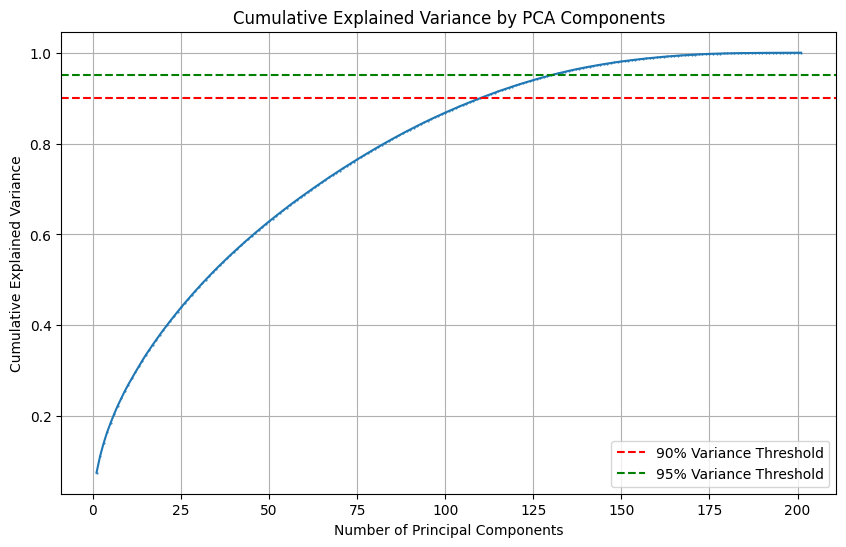

In [320]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Fit PCA 
pca = PCA()
temp_pca = pca.fit_transform(x_train) 

# CUMULATIVE explained variance
cumulative_evr = np.cumsum(pca.explained_variance_ratio_)

# Plot 
plt.figure(figsize=(10, 6))

# cumulative variance line
plt.plot(range(1, len(cumulative_evr) + 1), cumulative_evr, marker='o', linestyle='-', markersize=0.5)

# horizontal lines for common thresholds (90% and 95%)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance Threshold')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% Variance Threshold')

plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend(loc='lower right')
plt.grid(True , axis='both' )

plt.show()

In [321]:
test_data.isna().sum()

MSSubClass                   0
LotFrontage                  0
LotArea                      0
OverallQual                  0
OverallCond                  0
YearBuilt                    0
YearRemodAdd                 0
BsmtFinSF1                   0
BsmtUnfSF                    0
TotalBsmtSF                  0
1stFlrSF                     0
2ndFlrSF                     0
GrLivArea                    0
BsmtFullBath                 0
FullBath                     0
HalfBath                     0
BedroomAbvGr                 0
TotRmsAbvGrd                 0
Fireplaces                   0
GarageYrBlt                  0
GarageCars                   0
GarageArea                   0
OpenPorchSF                  0
MoSold                       0
YrSold                       0
Has_MasVnrArea               0
Has_BsmtFinSF2               0
Has_LowQualFinSF             0
Has_BsmtHalfBath             0
Has_WoodDeckSF               0
Has_EnclosedPorch            0
Has_3SsnPorch                0
Has_Scre

From PCA graph we can use 130 components for explaining 90% of our data

In [322]:
pca = PCA(n_components=130)

x_train_pca = pca.fit_transform(x_train)

x_test_pca = pca.transform(x_test)
test_data_pca = pca.transform(test_data)

pca_cols = [f"PCA_{i}" for i in range(1,131)]

x_train_final = pd.DataFrame(x_train_pca, columns=pca_cols)
x_test_final = pd.DataFrame(x_test_pca, columns=pca_cols)
test_data_final = pd.DataFrame(test_data_pca, columns=pca_cols)

print(f"Original training shape: {x_train.shape}")
print(f"Final PCA training shape: {x_train_final.shape}")

Original training shape: (1314, 201)
Final PCA training shape: (1314, 130)


### Models Training and Evaluation

In [323]:
from sklearn.linear_model import LinearRegression , Lasso , Ridge , ElasticNet
from sklearn.metrics import mean_absolute_error , mean_absolute_percentage_error , mean_squared_error , root_mean_squared_error
from sklearn.preprocessing import PowerTransformer

transformer = PowerTransformer(method='yeo-johnson',standardize=True)

y_train_transformed = transformer.fit_transform(y_train.to_frame())

models = {
    "Linear Regression" : LinearRegression(),
    "Lasso Regression" : Lasso(alpha=1),
    "Ridge Regression" : Ridge(alpha=1),
    "Elastic Net" : ElasticNet(alpha=1 , l1_ratio=0.5)
}

Mean Absoulute Error for Linear Regression model is : 16885.90
Mean Absoulute Error Percentage for Linear Regression model is : 9.91%
Mean Square Error for Linear Regression model is : 666758606.28
Root Mean Square Error for Linear Regression model is : 25821.67


c:\Users\sohil\anaconda3\envs\AICourse\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


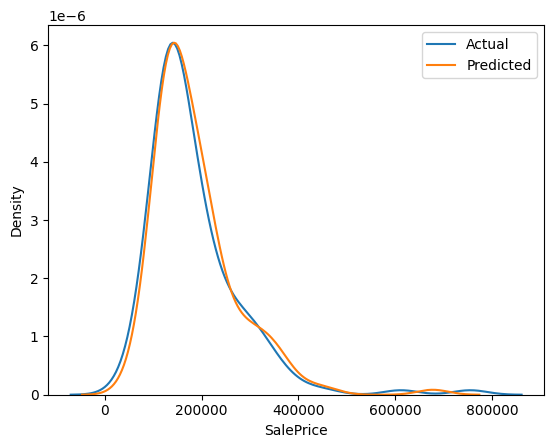

c:\Users\sohil\anaconda3\envs\AICourse\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(




Mean Absoulute Error for Lasso Regression model is : 34942.67
Mean Absoulute Error Percentage for Lasso Regression model is : 17.02%
Mean Square Error for Lasso Regression model is : 4511617243.28
Root Mean Square Error for Lasso Regression model is : 67168.57


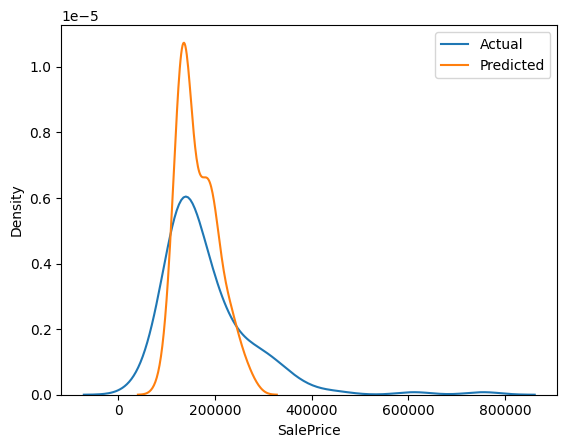



Mean Absoulute Error for Ridge Regression model is : 16880.75
Mean Absoulute Error Percentage for Ridge Regression model is : 9.91%
Mean Square Error for Ridge Regression model is : 666935375.90
Root Mean Square Error for Ridge Regression model is : 25825.09


c:\Users\sohil\anaconda3\envs\AICourse\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


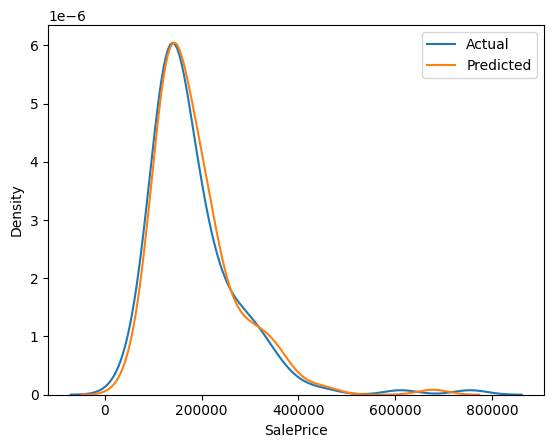



Mean Absoulute Error for Elastic Net model is : 31037.64
Mean Absoulute Error Percentage for Elastic Net model is : 14.89%
Mean Square Error for Elastic Net model is : 3719876071.81
Root Mean Square Error for Elastic Net model is : 60990.79


c:\Users\sohil\anaconda3\envs\AICourse\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


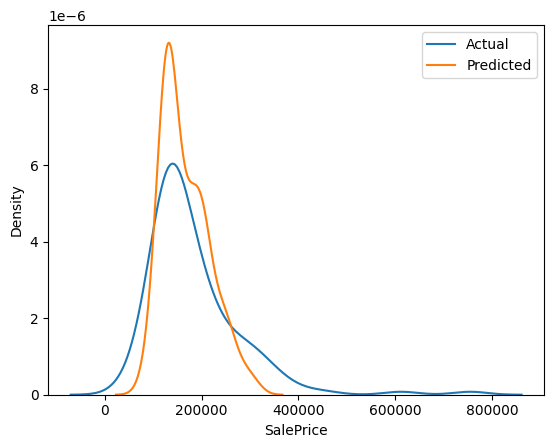

In [324]:
for modal_name , model in models.items():

    model.fit(x_train_final,y_train_transformed)
    predictions = model.predict(x_test_final)

    transformed_predictions = transformer.inverse_transform(predictions.reshape(-1,1)).flatten()
    
    mae = mean_absolute_error(y_test,transformed_predictions)
    mae_pct = mean_absolute_percentage_error(y_test,transformed_predictions)*100
    mse = mean_squared_error(y_test,transformed_predictions)
    rmse = root_mean_squared_error(y_test,transformed_predictions)
    
    print(f"Mean Absoulute Error for {modal_name} model is : {mae:.2f}")
    print(f"Mean Absoulute Error Percentage for {modal_name} model is : {mae_pct:.2f}%")
    print(f"Mean Square Error for {modal_name} model is : {mse:.2f}")
    print(f"Root Mean Square Error for {modal_name} model is : {rmse:.2f}")
    
    sns.kdeplot(y_test,label = "Actual")
    sns.kdeplot(transformed_predictions , label = "Predicted")
    plt.legend()
    plt.show()
    print("\n")

### Result Output Predictions

In [325]:
best_model = models["Ridge Regression"]

predictions = best_model.predict(test_data_final)

transformed_predictions = transformer.inverse_transform(predictions.reshape(-1,1))

rounded_predictions = [round(x,4) for x in transformed_predictions.flatten()]

result = pd.DataFrame({
    "Id" : test_ids,
    "SalePrice" : rounded_predictions
})

result.to_csv("result.csv",index=False)

c:\Users\sohil\anaconda3\envs\AICourse\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(
